***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.10 短间距、单碟与联合成像](9_10_short_spacing_and_feather.ipynb)
    * 下一节： [9.12 宽场方向相关成像](9_12_direction_dependent_widefield_imaging.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.11 偏振高级实践：交叉手相位校准与 RM synthesis

`9.9` 已经把偏振成像的入口建立起来了，但真实数据处理往往不会停在 “画出 `Q/U` 图和做一条 RM 直线拟合” 这一步。继续往下走，你很快就会遇到两个更专业、也更常见的问题：

- 如果交叉手相位（`cross-hand phase`、`XY phase` 或 `R-L phase`）没有校准好，整个偏振角会被系统性旋转，而且这种旋转还可能随频率变化；
- 如果真实源在 Faraday 深度上并不只有一个分量，那么简单的 $\chi(\lambda^2)$ 直线拟合就会失效，这时需要转向 `RM synthesis`。

这一节把这两件事连成一条更接近真实工作的判断链：

- 先用一个已知偏振校准源求解频率依赖的交叉手相位；
- 再把这个解应用到一个 Faraday-thin 目标上，比较校准前后的 RM 偏差；
- 最后构造一个双 Faraday 分量目标，说明为什么单一 RM 拟合不够，以及 `RM synthesis` 为什么有必要。


***


In [2]:
c_light = 0.299792458


def complex_polarization_spectrum(
    freqs_ghz, lambda2, ref_freq_ghz, lambda2_ref, components
):
    spectrum = np.zeros(freqs_ghz.size, dtype=complex)
    for comp in components:
        amp = comp["p_ref"] * (freqs_ghz / ref_freq_ghz) ** comp.get("alpha", 0.0)
        phase = 2.0 * (
            np.deg2rad(comp["chi0_deg"]) + comp["phi"] * (lambda2 - lambda2_ref)
        )
        spectrum += amp * np.exp(1j * phase)
    return spectrum


def wrap_evpa_deg(angle_deg):
    return ((angle_deg + 90.0) % 180.0) - 90.0


def evpa_deg(spectrum):
    return wrap_evpa_deg(0.5 * np.rad2deg(np.angle(spectrum)))


def fit_linear_rm(lambda2, spectrum, min_p):
    p_spec = np.abs(spectrum)
    valid = p_spec > min_p
    chi = np.full_like(lambda2, np.nan, dtype=float)
    model = np.full_like(lambda2, np.nan, dtype=float)
    if np.count_nonzero(valid) < 3:
        return np.nan, np.nan, chi, model, valid, np.nan
    chi_valid = 0.5 * np.unwrap(np.angle(spectrum[valid]))
    slope, intercept = np.polyfit(lambda2[valid], chi_valid, 1)
    chi[valid] = chi_valid
    model[valid] = intercept + slope * lambda2[valid]
    residual_rms_deg = np.sqrt(
        np.mean(np.rad2deg(chi_valid - model[valid]) ** 2)
    )
    return intercept, slope, chi, model, valid, residual_rms_deg


def rm_synthesis(lambda2, spectrum, phi_axis, weights=None):
    if weights is None:
        weights = np.ones_like(lambda2)
    lambda2_0 = np.sum(weights * lambda2) / np.sum(weights)
    phase = np.exp(-2j * np.outer(phi_axis, lambda2 - lambda2_0))
    fdf = phase @ (weights * spectrum) / np.sum(weights)
    rmsf = phase @ weights / np.sum(weights)
    return lambda2_0, fdf, rmsf


def extract_faraday_peaks(phi_axis, amplitude, min_sep, nmax):
    peaks = []
    for idx in np.argsort(amplitude)[::-1]:
        if not peaks or all(abs(phi_axis[idx] - peak[0]) > min_sep for peak in peaks):
            peaks.append((phi_axis[idx], amplitude[idx]))
        if len(peaks) >= nmax:
            break
    return peaks


def rm_resolution(lambda2):
    return 2.0 * np.sqrt(3.0) / (lambda2.max() - lambda2.min())


freqs_ghz = np.linspace(1.0, 2.0, 64)
lambda2 = (c_light / freqs_ghz) ** 2
ref_index = int(np.argmin(np.abs(freqs_ghz - np.median(freqs_ghz))))
ref_freq_ghz = freqs_ghz[ref_index]
lambda2_ref = lambda2[ref_index]

calibrator_true = complex_polarization_spectrum(
    freqs_ghz,
    lambda2,
    ref_freq_ghz,
    lambda2_ref,
    [{"p_ref": 0.075, "chi0_deg": 22.0, "phi": 55.0, "alpha": -0.2}],
)
simple_target_true = complex_polarization_spectrum(
    freqs_ghz,
    lambda2,
    ref_freq_ghz,
    lambda2_ref,
    [{"p_ref": 0.052, "chi0_deg": -12.0, "phi": 85.0, "alpha": -0.5}],
)
complex_target_true = complex_polarization_spectrum(
    freqs_ghz,
    lambda2,
    ref_freq_ghz,
    lambda2_ref,
    [
        {"p_ref": 0.040, "chi0_deg": 10.0, "phi": 35.0, "alpha": -0.3},
        {"p_ref": 0.040, "chi0_deg": -20.0, "phi": 165.0, "alpha": -0.6},
    ],
)

crosshand_phase_true_deg = (
    35.0
    + 75.0 * (freqs_ghz - ref_freq_ghz)
    + 18.0 * np.sin(2.0 * np.pi * (freqs_ghz - 1.0) / 0.45)
)
crosshand_phase_true_rad = np.deg2rad(crosshand_phase_true_deg)
noise_std = 6.0e-4

calibrator_obs = calibrator_true * np.exp(1j * crosshand_phase_true_rad)
calibrator_obs += noise_std * (
    RNG.normal(size=freqs_ghz.size) + 1j * RNG.normal(size=freqs_ghz.size)
)

simple_target_obs = simple_target_true * np.exp(1j * crosshand_phase_true_rad)
simple_target_obs += noise_std * (
    RNG.normal(size=freqs_ghz.size) + 1j * RNG.normal(size=freqs_ghz.size)
)

complex_target_obs = complex_target_true * np.exp(1j * crosshand_phase_true_rad)
complex_target_obs += noise_std * (
    RNG.normal(size=freqs_ghz.size) + 1j * RNG.normal(size=freqs_ghz.size)
)

crosshand_phase_solution_rad = np.unwrap(
    np.angle(calibrator_obs * np.conj(calibrator_true))
)
crosshand_phase_residual_deg = np.rad2deg(
    np.angle(
        np.exp(1j * (crosshand_phase_solution_rad - np.unwrap(crosshand_phase_true_rad)))
    )
)

calibrator_corrected = calibrator_obs * np.exp(-1j * crosshand_phase_solution_rad)
simple_target_corrected = simple_target_obs * np.exp(-1j * crosshand_phase_solution_rad)
complex_target_corrected = complex_target_obs * np.exp(-1j * crosshand_phase_solution_rad)

phi_axis = np.linspace(-300.0, 300.0, 1801)
broad_mask = np.ones_like(freqs_ghz, dtype=bool)
narrow_mask = (freqs_ghz >= 1.30) & (freqs_ghz <= 1.55)


### 9.11.1 先把交叉手相位校准好，否则偏振角会整段被旋转

对线偏振复量 $P = Q + iU$ 来说，频率依赖的交叉手相位误差本质上就是一个复平面旋转项。如果不先把它解掉：

- `EVPA` 会被系统性扭曲；
- 单一 RM 拟合会出现偏差；
- `RM synthesis` 的相位参考也会受到污染。

下面用一个已知偏振校准源来解这个相位项，并比较真实相位偏移、求解结果和校准前后的 `EVPA`。


交叉手相位在这段频带内约变化 -1.9 到 90.8 deg
交叉手相位求解残差 RMS ≈ 0.45 deg
校准源真实 RM = +55.0 rad/m^2，校准前估计 = +46.5，校准后估计 = +55.0


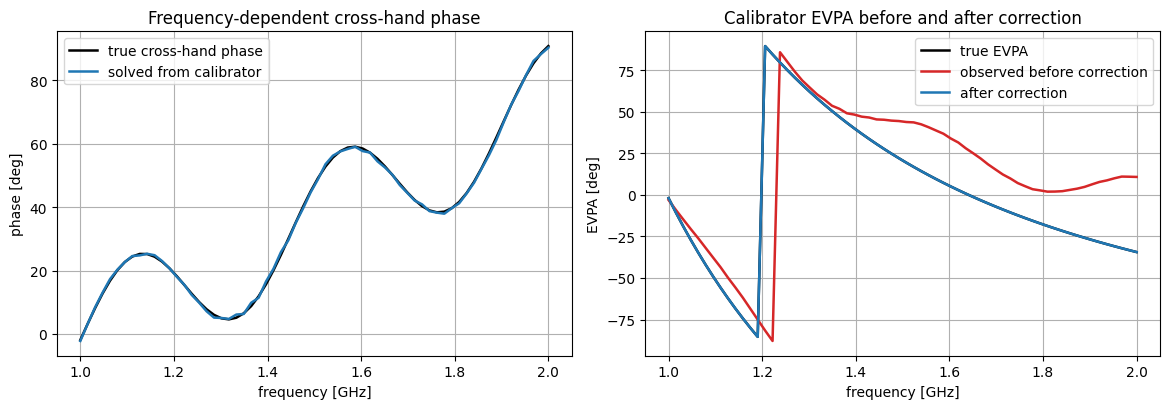

In [3]:
calibrator_fit_true = fit_linear_rm(lambda2, calibrator_true, min_p=0.002)
calibrator_fit_obs = fit_linear_rm(lambda2, calibrator_obs, min_p=0.002)
calibrator_fit_corr = fit_linear_rm(lambda2, calibrator_corrected, min_p=0.002)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))

axes[0].plot(freqs_ghz, crosshand_phase_true_deg, color="black", lw=1.8, label="true cross-hand phase")
axes[0].plot(
    freqs_ghz,
    np.rad2deg(crosshand_phase_solution_rad),
    color="tab:blue",
    lw=1.8,
    label="solved from calibrator",
)
axes[0].set_xlabel("frequency [GHz]")
axes[0].set_ylabel("phase [deg]")
axes[0].set_title("Frequency-dependent cross-hand phase")
axes[0].legend(loc="upper left")

axes[1].plot(freqs_ghz, evpa_deg(calibrator_true), color="black", lw=1.8, label="true EVPA")
axes[1].plot(freqs_ghz, evpa_deg(calibrator_obs), color="tab:red", lw=1.8, label="observed before correction")
axes[1].plot(freqs_ghz, evpa_deg(calibrator_corrected), color="tab:blue", lw=1.8, label="after correction")
axes[1].set_xlabel("frequency [GHz]")
axes[1].set_ylabel("EVPA [deg]")
axes[1].set_title("Calibrator EVPA before and after correction")
axes[1].legend(loc="best")

plt.tight_layout()

print(
    f"交叉手相位在这段频带内约变化 "
    f"{crosshand_phase_true_deg.min():.1f} 到 {crosshand_phase_true_deg.max():.1f} deg"
)
print(
    f"交叉手相位求解残差 RMS ≈ {np.std(crosshand_phase_residual_deg):.2f} deg"
)
print(
    f"校准源真实 RM = +55.0 rad/m^2，"
    f"校准前估计 = {calibrator_fit_obs[1]:+.1f}，"
    f"校准后估计 = {calibrator_fit_corr[1]:+.1f}"
)


这里要建立的专业判断是：**即使你已经有了 `Q/U` 数据，偏振角也并不自动可信。** 交叉手相位没有处理好，后面一整条偏振分析链都会偏掉。


### 9.11.2 把解应用到 Faraday-thin 目标：RM 偏差会明显收敛

下面构造一个单一 Faraday 分量目标。它本来满足简单的 $\chi(\lambda^2)$ 线性关系，所以非常适合拿来检验交叉手相位校准有没有真正生效。


simple target 真实 RM = +85.0 rad/m^2，校准前估计 = +76.5，校准后估计 = +85.0
校准后 RM 偏差约从 8.5 降到 0.0 rad/m^2


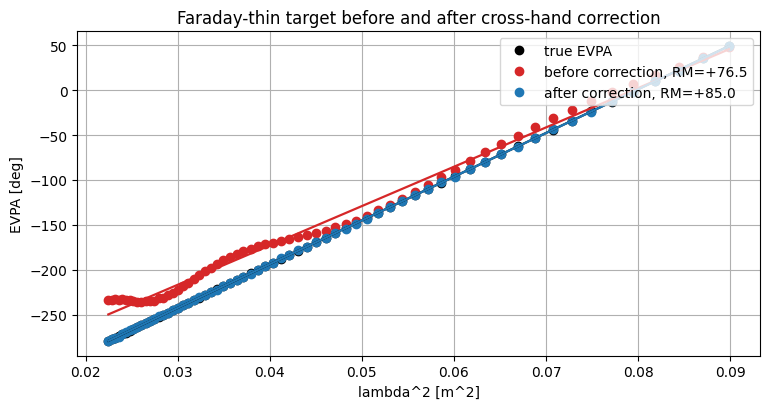

In [4]:
simple_fit_true = fit_linear_rm(lambda2, simple_target_true, min_p=0.002)
simple_fit_obs = fit_linear_rm(lambda2, simple_target_obs, min_p=0.002)
simple_fit_corr = fit_linear_rm(lambda2, simple_target_corrected, min_p=0.002)

fig, ax = plt.subplots(figsize=(7.8, 4.2))

ax.plot(
    lambda2[simple_fit_true[4]],
    np.rad2deg(simple_fit_true[2][simple_fit_true[4]]),
    "o",
    color="black",
    label="true EVPA",
)
ax.plot(
    lambda2[simple_fit_obs[4]],
    np.rad2deg(simple_fit_obs[2][simple_fit_obs[4]]),
    "o",
    color="tab:red",
    label=f"before correction, RM={simple_fit_obs[1]:+.1f}",
)
ax.plot(
    lambda2[simple_fit_corr[4]],
    np.rad2deg(simple_fit_corr[2][simple_fit_corr[4]]),
    "o",
    color="tab:blue",
    label=f"after correction, RM={simple_fit_corr[1]:+.1f}",
)
ax.plot(lambda2[simple_fit_true[4]], np.rad2deg(simple_fit_true[3][simple_fit_true[4]]), color="black", lw=1.6)
ax.plot(lambda2[simple_fit_obs[4]], np.rad2deg(simple_fit_obs[3][simple_fit_obs[4]]), color="tab:red", lw=1.6)
ax.plot(lambda2[simple_fit_corr[4]], np.rad2deg(simple_fit_corr[3][simple_fit_corr[4]]), color="tab:blue", lw=1.6)
ax.set_xlabel("lambda^2 [m^2]")
ax.set_ylabel("EVPA [deg]")
ax.set_title("Faraday-thin target before and after cross-hand correction")
ax.legend(loc="upper right")

plt.tight_layout()

print(
    f"simple target 真实 RM = +85.0 rad/m^2，"
    f"校准前估计 = {simple_fit_obs[1]:+.1f}，"
    f"校准后估计 = {simple_fit_corr[1]:+.1f}"
)
print(
    f"校准后 RM 偏差约从 {abs(simple_fit_obs[1] - 85.0):.1f} "
    f"降到 {abs(simple_fit_corr[1] - 85.0):.1f} rad/m^2"
)


这一步说明：**交叉手相位校准解决的不只是“角度好不好看”的问题，而是会直接影响你最终报告的 RM 数值。**


### 9.11.3 一旦源里有多个 Faraday 分量，单一 RM 拟合就会变得不可靠

下面把目标换成两个 Faraday-thin 分量的叠加。这里即使交叉手相位已经校准好，$\chi(\lambda^2)$ 也不再严格线性：

- `EVPA` 会出现明显弯折；
- 线偏振强度会随频率振荡；
- 用一条直线去拟合时，得到的 RM 往往没有清晰物理意义。


双分量目标若仍做单一 RM 拟合，会得到 RM ≈ +115.7 rad/m^2
但这条直线的 EVPA 残差 RMS 仍有 ≈ 49.2 deg


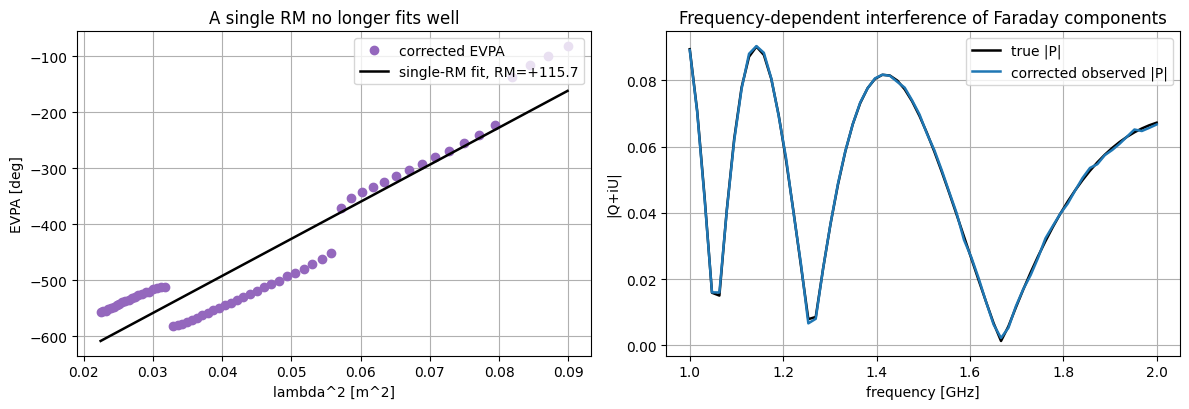

In [5]:
complex_fit_corr = fit_linear_rm(lambda2, complex_target_corrected, min_p=0.005)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))

axes[0].plot(
    lambda2[complex_fit_corr[4]],
    np.rad2deg(complex_fit_corr[2][complex_fit_corr[4]]),
    "o",
    color="tab:purple",
    label="corrected EVPA",
)
axes[0].plot(
    lambda2[complex_fit_corr[4]],
    np.rad2deg(complex_fit_corr[3][complex_fit_corr[4]]),
    color="black",
    lw=1.8,
    label=f"single-RM fit, RM={complex_fit_corr[1]:+.1f}",
)
axes[0].set_xlabel("lambda^2 [m^2]")
axes[0].set_ylabel("EVPA [deg]")
axes[0].set_title("A single RM no longer fits well")
axes[0].legend(loc="upper right")

axes[1].plot(freqs_ghz, np.abs(complex_target_true), color="black", lw=1.8, label="true |P|")
axes[1].plot(
    freqs_ghz,
    np.abs(complex_target_corrected),
    color="tab:blue",
    lw=1.8,
    label="corrected observed |P|",
)
axes[1].set_xlabel("frequency [GHz]")
axes[1].set_ylabel("|Q+iU|")
axes[1].set_title("Frequency-dependent interference of Faraday components")
axes[1].legend(loc="upper right")

plt.tight_layout()

print(
    f"双分量目标若仍做单一 RM 拟合，会得到 RM ≈ {complex_fit_corr[1]:+.1f} rad/m^2"
)
print(
    f"但这条直线的 EVPA 残差 RMS 仍有 ≈ {complex_fit_corr[5]:.1f} deg"
)


这正是 `RM synthesis` 的工作背景。它不是为了“更复杂而复杂”，而是因为单一 RM 模型已经不足以描述真实偏振频谱。


### 9.11.4 用 RM synthesis 在 Faraday 深度空间里分开多分量

现在对同一个双分量目标做 `RM synthesis`。我们同时比较：

- 全带宽情形：Faraday 深度分辨率较好，两个分量可以被区分；
- 窄带宽情形：Faraday 深度分辨率明显变差，两个分量会混成一个宽峰。


全带宽 RM synthesis 的两个主峰约位于 +171.0, +29.0 rad/m^2
窄带宽 RM synthesis 的主峰约位于 +100.3, +65.0 rad/m^2
全带宽 Faraday 深度分辨率约 ≈ 51.4 rad/m^2
窄带宽 Faraday 深度分辨率约 ≈ 228.8 rad/m^2


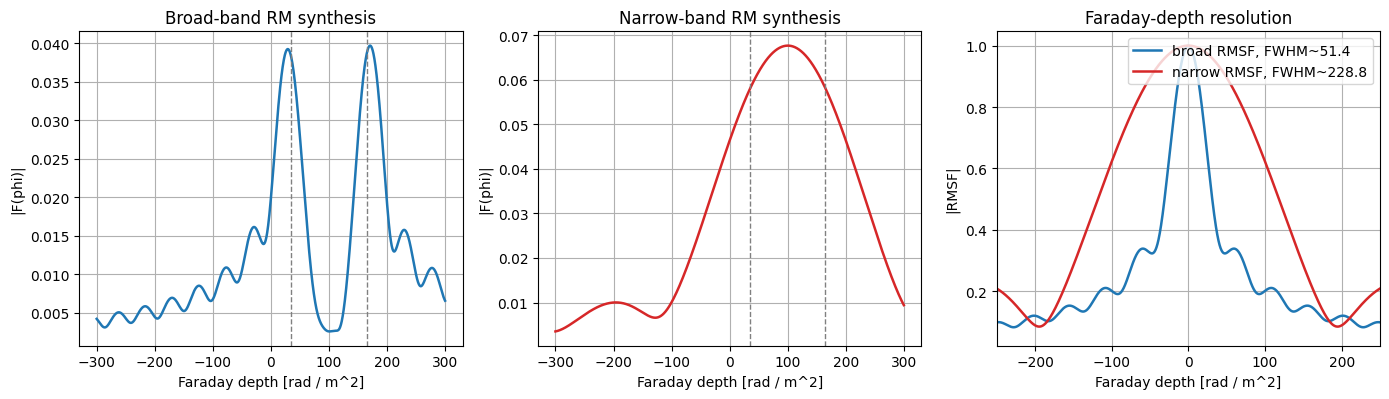

In [6]:
_, fdf_broad, rmsf_broad = rm_synthesis(
    lambda2[broad_mask], complex_target_corrected[broad_mask], phi_axis
)
_, fdf_narrow, rmsf_narrow = rm_synthesis(
    lambda2[narrow_mask], complex_target_corrected[narrow_mask], phi_axis
)

broad_peaks = extract_faraday_peaks(phi_axis, np.abs(fdf_broad), min_sep=35.0, nmax=3)
narrow_peaks = extract_faraday_peaks(phi_axis, np.abs(fdf_narrow), min_sep=35.0, nmax=3)
broad_resolution = rm_resolution(lambda2[broad_mask])
narrow_resolution = rm_resolution(lambda2[narrow_mask])

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.1))

axes[0].plot(phi_axis, np.abs(fdf_broad), color="tab:blue", lw=1.8)
axes[0].axvline(35.0, color="gray", ls="--", lw=1.0)
axes[0].axvline(165.0, color="gray", ls="--", lw=1.0)
axes[0].set_xlabel("Faraday depth [rad / m^2]")
axes[0].set_ylabel("|F(phi)|")
axes[0].set_title("Broad-band RM synthesis")

axes[1].plot(phi_axis, np.abs(fdf_narrow), color="tab:red", lw=1.8)
axes[1].axvline(35.0, color="gray", ls="--", lw=1.0)
axes[1].axvline(165.0, color="gray", ls="--", lw=1.0)
axes[1].set_xlabel("Faraday depth [rad / m^2]")
axes[1].set_ylabel("|F(phi)|")
axes[1].set_title("Narrow-band RM synthesis")

axes[2].plot(phi_axis, np.abs(rmsf_broad), color="tab:blue", lw=1.8, label=f"broad RMSF, FWHM~{broad_resolution:.1f}")
axes[2].plot(phi_axis, np.abs(rmsf_narrow), color="tab:red", lw=1.8, label=f"narrow RMSF, FWHM~{narrow_resolution:.1f}")
axes[2].set_xlim(-250.0, 250.0)
axes[2].set_xlabel("Faraday depth [rad / m^2]")
axes[2].set_ylabel("|RMSF|")
axes[2].set_title("Faraday-depth resolution")
axes[2].legend(loc="upper right")

plt.tight_layout()

print(
    "全带宽 RM synthesis 的两个主峰约位于 "
    + ", ".join([f"{peak[0]:+.1f}" for peak in broad_peaks[:2]])
    + " rad/m^2"
)
print(
    "窄带宽 RM synthesis 的主峰约位于 "
    + ", ".join([f"{peak[0]:+.1f}" for peak in narrow_peaks[:2]])
    + " rad/m^2"
)
print(f"全带宽 Faraday 深度分辨率约 ≈ {broad_resolution:.1f} rad/m^2")
print(f"窄带宽 Faraday 深度分辨率约 ≈ {narrow_resolution:.1f} rad/m^2")


这里最重要的结论有两个：

- `RM synthesis` 的能力不仅取决于信噪比，也强烈取决于 $\lambda^2$ 覆盖；
- 带宽一旦变窄，Faraday 深度分辨率会迅速恶化，多个分量就可能在 Faraday 空间里混成一个结构。


### 9.11.5 与真实软件流程的对应

若把这个教学实验映射回真实偏振数据处理，通常会落到下面这些动作上：

- 在总强度校准之后，继续求解 cross-hand delay、`XY phase` / `R-L phase` 和 `D-term`；
- 用偏振校准源把交叉手相位随频率的旋转校准干净；
- 对 Faraday-thin 源，可以先做 `RM fit` 作为快速入口；
- 对多分量或 Faraday-thick 源，应进入 `RM synthesis`、`RM-CLEAN`、Faraday depth 建模或 `QU-fitting`；
- 始终检查带宽去极化、beam depolarization、主波束偏振响应和频率采样是否足以支撑物理解释。

这个 notebook 传达的专业判断是：**交叉手相位校准和 RM synthesis 不是两个孤立技巧，而是同一条偏振分析链上前后相接的关键环节。**
